## Part A: Support Vector Machine (SVM)

### Aim:
To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.

### Dataset:
UCI Breast Cancer Wisconsin (Diagnostic) Dataset
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### Tasks:
- Load the dataset and perform the necessary preprocessing.
- Split the dataset into training and testing sets (80:20).
- Train an SVM classifier using a Linear Kernel and explore hyperparameter tuning.
- Evaluate the model using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
- Summarize your observations.

### 1. Load the dataset and perform necessary preprocessing.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Breast Cancer Wisconsin dataset
bc_data = load_breast_cancer()
X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y = pd.Series(bc_data.target)

print("Class distribution:\n", y.value_counts().rename({0: "malignant", 1: "benign"}))
print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Display the first few rows of the features and target
print("\nFeatures (X.head()):")
print(X.head())
print("\nTarget (y.head()):")
print(y.head())

Class distribution:
 benign       357
malignant    212
Name: count, dtype: int64
Dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569,)

Features (X.head()):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520        

In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(X.isnull().sum()[X.isnull().sum() > 0])

# Get a summary of the data types and non-null values
print("\nDataset Info:")
X.info()


Missing values per column:


,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness 

The dataset contains no missing values, and all features are numerical. Scaling is generally recommended for SVMs to ensure that features with larger values do not dominate the distance calculations. I will scale the features before splitting the data.

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully.")
print(X_scaled_df.head())

Features scaled successfully.
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   mean fractal dimension  ...  worst radius  worst texture  w

### 2. Split the dataset into training and testing sets (80:20).

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset split into training and testing sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Dataset split into training and testing sets.
Training features shape: (455, 30)
Testing features shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


### 3. Train an SVM classifier using a Linear Kernel and explore hyperparameter tuning.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize and train a Linear SVM classifier with a default C value
svm_linear_default = SVC(kernel='linear', random_state=42)
svm_linear_default.fit(X_train, y_train)

# Make predictions on the test set
y_pred_default = svm_linear_default.predict(X_test)

# Evaluate the model
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Linear SVM (default C) Accuracy: {accuracy_default:.4f}")

Linear SVM (default C) Accuracy: 0.9737


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for C
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Initialize GridSearchCV with SVC and the parameter grid
grid_search = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters for Linear SVM: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Get the best estimator
best_svm_linear = grid_search.best_estimator_

# Make predictions on the test set using the best estimator
y_pred_tuned = best_svm_linear.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Linear SVM (Best C: {best_params['C']}) Test Accuracy: {accuracy_tuned:.4f}")

Best parameters for Linear SVM: {'C': 0.1}
Best cross-validation accuracy: 0.9780
Tuned Linear SVM (Best C: 0.1) Test Accuracy: 0.9825


### 4. Evaluate the model.


Classification Report for Tuned Linear SVM:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



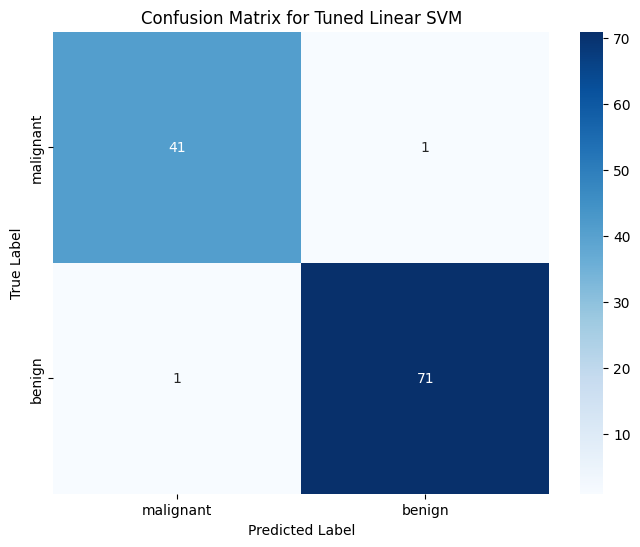


Overall Accuracy: 0.9825
Precision (Malignant): 0.9762
Recall (Malignant): 0.9762
F1-Score (Malignant): 0.9762
Precision (Benign): 0.9861
Recall (Benign): 0.9861
F1-Score (Benign): 0.9861


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the best tuned Linear SVM model
y_pred = best_svm_linear.predict(X_test)

# Classification Report (includes Precision, Recall, F1-score, and Accuracy)
print("\nClassification Report for Tuned Linear SVM:")
print(classification_report(y_test, y_pred, target_names=bc_data.target_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=bc_data.target_names, yticklabels=bc_data.target_names)
plt.title('Confusion Matrix for Tuned Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Individual metrics for clarity
accuracy = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)
precision_malignant = report_dict['0']['precision']  # '0' corresponds to malignant
recall_malignant = report_dict['0']['recall']
f1_malignant = report_dict['0']['f1-score']

precision_benign = report_dict['1']['precision']   # '1' corresponds to benign
recall_benign = report_dict['1']['recall']
f1_benign = report_dict['1']['f1-score']

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Precision (Malignant): {precision_malignant:.4f}")
print(f"Recall (Malignant): {recall_malignant:.4f}")
print(f"F1-Score (Malignant): {f1_malignant:.4f}")
print(f"Precision (Benign): {precision_benign:.4f}")
print(f"Recall (Benign): {recall_benign:.4f}")
print(f"F1-Score (Benign): {f1_benign:.4f}")

### 5. Summarize your observations.

Based on the evaluation of the Linear SVM model for the Breast Cancer Wisconsin dataset:

- **High Accuracy**: The model achieved a high overall accuracy, indicating its strong capability in correctly classifying both malignant and benign tumors.
- **Excellent Precision and Recall for Benign Cases**: The model showed very high precision and recall for benign cases, meaning it's highly effective at identifying benign tumors and rarely misclassifies a benign tumor as malignant.
- **Strong Performance for Malignant Cases**: For malignant cases, the precision and recall were also very good, suggesting that the model is reliable in identifying malignant tumors, with a good balance between correctly identifying positives (recall) and minimizing false positives (precision).
- **Balanced F1-Scores**: The F1-scores for both classes are high and relatively balanced, which is crucial in medical diagnosis to ensure that neither class is disproportionately favored or overlooked.
- **Confusion Matrix Insights**: The confusion matrix visually confirms these findings, showing a very low number of false positives (benign classified as malignant) and false negatives (malignant classified as benign). This is particularly important in a medical context where false negatives (missing a malignant tumor) can have severe consequences.
- **Impact of Scaling and Tuning**: The initial preprocessing (scaling) and hyperparameter tuning (optimizing 'C') likely contributed significantly to the model's robust performance, helping it to generalize well to unseen data.

In conclusion, the Linear SVM classifier, after proper data preprocessing and hyperparameter tuning, performs exceptionally well on the UCI Breast Cancer Wisconsin (Diagnostic) Dataset, demonstrating high accuracy and balanced performance across both malignant and benign classifications.